In [44]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns

import config
from data_utils import best_players_plots, table_simulation, expected_stats_vs_actuals, sort_data, colors_config

In [45]:
data = pd.read_parquet(config.TIDY_DATA_PATH)

In [46]:
data = sort_data(data)
data.head()

,web_name_id,first_name_id,second_name_id,status_id,team_name_id,position_id,season_id,player_code_id,team_code_id,gw_id,match_id,recoveries,dreamteam_count,creativity,tackles_won_percent,corners_and_indirect_freekicks_order,bps,accurate_passes,transfers_in,expected_goals_conceded,ground_duels_won,duels_lost,tackles_won,finish_min,xgot,ep_this,was_fouled,accurate_long_balls_percent,accurate_passes_percent,ground_duels_won_percent,transfers_out,touches,tackles,interceptions,event_points,transfers_out_event,clearances,gk_accurate_long_balls,now_cost_rank,goals,team_goals_conceded,value_form,fouls_committed,threat,penalties_missed,bonus,blocks,high_claim,ep_next,shots_on_target,value_season,minutes_played,dribbled_past,expected_goals,influence,now_cost,chance_of_playing_next_round,penalties_scored,cost_change_start,ict_index,id,touches_opposition_box,cost_change_event,selected_rank,penalties_order,form,selected_by_percent,expected_assists,accurate_crosses,start_min,team_strength,final_third_passes,accurate_long_balls,aerial_duels_won,offsides,total_shots,total_points,expected_goal_involvements,xa,aerial_duels_won_percent,goals_prevented,chances_created,goals_conceded,xgot_faced,direct_freekicks_order,gk_accurate_passes,successful_dribbles,headed_clearances,big_chances_missed,saves,sweeper_actions,duels_won,accurate_crosses_percent,successful_dribbles_percent,assists,xg,transfers_in_event,chance_of_playing_this_round,position,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90
0,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,1,24-25-prem-everton-vs-brighton-&-hove-albion,0,0,43.8,50,1,10,28,513,0.45,4,2,2,82,0.0,1.6,0,33,85,80,421,48,4,0,2,421,0,0,172,0,0,0.4,1,4,0,0,2,0,1.6,0,0.4,82,0,0.0,22.4,5.0,0,0,0,7.0,134,2,0,471,6,2.0,0.1,0.11,2,0,3,2,1,0,0,0,2,0.11,0.11,0,0.0,3,0,0.0,7,0,0,0,0,0,0,4,29,0,0,0.0,513,0,MID,0.0,0.120732,0.120732,0.493902
1,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,2,24-25-prem-brighton-&-hove-albion-vs-mancheste...,2,0,66.2,0,1,22,22,2267,1.77,3,1,0,73,0.0,2.0,1,0,73,75,1548,42,1,1,2,635,2,0,177,0,1,0.4,1,12,0,0,0,0,1.0,1,0.8,73,0,0.16,28.6,5.0,0,0,0,10.7,134,2,0,448,6,2.0,0.1,0.15,1,0,3,6,0,0,0,2,4,0.31,0.04,0,0.0,1,0,0.0,7,0,1,0,0,0,0,3,100,100,0,0.16,1189,0,MID,0.19726,0.049315,0.382192,2.182192
2,Milner,James,Milner,d,Brighton,Midfielder,2425,15157,36,3,24-25-prem-arsenal-vs-brighton-&-hove-albion,0,0,66.3,0,1,24,2,4199,1.98,0,1,0,17,0.0,0.7,0,0,100,0,4535,4,0,1,1,1998,0,0,185,0,0,0.3,1,12,0,0,0,0,1.7,0,1.0,17,0,0.16,28.6,5.0,75,0,0,10.7,134,0,0,461,6,1.7,0.1,0.15,0,0,3,0,0,0,0,0,5,0.31,0.0,0,0.0,0,0,0.0,7,0,0,0,0,0,0,0,0,0,0,0.0,472,0,MID,0.0,0.0,1.641176,10.482353
3,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,38,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,0,0,66.3,0,8,27,0,5014,1.98,0,0,0,93,0.0,0.0,0,0,0,0,10991,1,0,0,1,0,0,0,192,0,0,0.0,0,12,0,0,0,0,0.0,0,1.2,1,0,0.16,28.6,5.0,100,0,0,10.7,134,0,0,586,6,0.2,0.0,0.15,0,93,3,1,0,0,0,0,6,0.31,0.0,0,0.0,0,0,0.0,7,0,0,0,0,0,0,0,0,0,0,0.0,0,0,MID,0.0,0.0,27.9,178.2
4,Milner,James,Milner,a,Brighton,Midfielder,2526,15157,36,1,25-26-prem-brighton-hove-albion-vs-fulham,0,0,0.1,0,5,3,1,14413,0.24,0,0,0,90,0.0,0.0,0,0,0,0,20304,1,0,0,1,497,0,0,283,0,1,0.0,0,0,0,0,0,0,-0.5,0,3.1,2,0,0.0,0.0,4.9,100,0,-1,0.0,170,0,0,467,1,0.0,0.1,0.0,0,0,3,0,0,0,0,0,1,0.0,0.0,0,0.0,0,0,0.0,7,0,0,0,0,0,0,0,0,0,0,0.0,113,0,MID,0.0,0.0,0.0,10.8


In [47]:
data.describe()

,season_id,player_code_id,team_code_id,gw_id,recoveries,dreamteam_count,creativity,tackles_won_percent,corners_and_indirect_freekicks_order,bps,accurate_passes,transfers_in,expected_goals_conceded,ground_duels_won,duels_lost,tackles_won,finish_min,xgot,ep_this,was_fouled,accurate_long_balls_percent,accurate_passes_percent,ground_duels_won_percent,transfers_out,touches,tackles,interceptions,event_points,transfers_out_event,clearances,gk_accurate_long_balls,now_cost_rank,goals,team_goals_conceded,value_form,fouls_committed,threat,penalties_missed,bonus,blocks,high_claim,ep_next,shots_on_target,value_season,minutes_played,dribbled_past,expected_goals,influence,now_cost,chance_of_playing_next_round,penalties_scored,cost_change_start,ict_index,id,touches_opposition_box,cost_change_event,selected_rank,penalties_order,form,selected_by_percent,expected_assists,accurate_crosses,start_min,team_strength,final_third_passes,accurate_long_balls,aerial_duels_won,offsides,total_shots,total_points,expected_goal_involvements,xa,aerial_duels_won_percent,goals_prevented,chances_created,goals_conceded,xgot_faced,direct_freekicks_order,gk_accurate_passes,successful_dribbles,headed_clearances,big_chances_missed,saves,sweeper_actions,duels_won,accurate_crosses_percent,successful_dribbles_percent,assists,xg,transfers_in_event,chance_of_playing_this_round,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90
count,22752.000000,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0,22752.0
mean,2474.652118,303830.615067,28.642141,17.190445,3.06039,0.295666,85.519313,17.072301,7.176072,95.398207,23.96185,348699.595156,8.352078,2.240418,3.156074,0.413986,79.262175,0.09348,2.490682,0.681742,18.482199,44.255714,24.681786,319500.931874,40.937368,1.036744,0.516922,2.738528,18256.113001,1.565709,0.350387,270.336366,0.092212,1.123198,0.461744,0.705828,77.723717,0.001538,1.793117,0.228727,0.051951,2.44528,0.289689,6.959498,63.424798,0.463959,0.811917,123.024288,5.347442,52.966772,0.006637,-0.789161,28.603943,352.362254,1.688291,-0.008131,250.062588,5.588212,2.495174,4.139223,0.525364,0.272679,12.104079,3.219805,3.430116,1.317071,0.923963,0.005934,0.784634,22.342387,1.337193,0.061754,17.935918,0.001804,0.617968,0.089179,0.087907,6.432753,1.396449,0.45385,0.809995,0.095025,0.184775,0.037447,3.164381,5.698005,11.900536,0.066104,0.094281,22203.696554,52.929413,0.192797,0.112534,3.721671,23.588701
std,50.493991,164150.101256,27.78874,10.084064,2.733508,0.833933,153.414518,34.441576,2.011359,136.604178,20.181593,929770.733855,11.727711,2.211717,2.786348,0.870137,28.263125,0.257443,2.070861,0.972536,32.21091,41.634467,32.548882,832069.299694,26.54739,1.376975,0.861707,2.991024,56107.971472,2.227745,1.600249,194.215193,0.321291,1.133358,0.339537,0.956716,158.103391,0.040298,4.127965,0.563326,0.320747,2.062308,0.617164,5.800074,32.758663,0.800324,1.90784,184.547104,1.275487,49.470735,0.086948,2.154076,44.766765,208.329508,2.2687,0.324758,187.437883,1.229839,1.91773,8.406293,1.029038,0.687017,27.466464,0.760427,3.648294,2.007684,1.404302,0.091913,1.187727,33.19235,2.681162,0.118629,33.393154,0.194168,1.000931,0.454228,0.411593,1.576679,5.717685,0.899004,1.42871,0.33783,0.852159,0.254371,2.732062,19.117281,29.05944,0.263911,0.207588,67760.278524,49.331162,1.2111,0.57

In [48]:
data.shape

(22752, 103)

In [49]:
data[~data['match_id'].str.contains('prem', na=False)]

,web_name_id,first_name_id,second_name_id,status_id,team_name_id,position_id,season_id,player_code_id,team_code_id,gw_id,match_id,recoveries,dreamteam_count,creativity,tackles_won_percent,corners_and_indirect_freekicks_order,bps,accurate_passes,transfers_in,expected_goals_conceded,ground_duels_won,duels_lost,tackles_won,finish_min,xgot,ep_this,was_fouled,accurate_long_balls_percent,accurate_passes_percent,ground_duels_won_percent,transfers_out,touches,tackles,interceptions,event_points,transfers_out_event,clearances,gk_accurate_long_balls,now_cost_rank,goals,team_goals_conceded,value_form,fouls_committed,threat,penalties_missed,bonus,blocks,high_claim,ep_next,shots_on_target,value_season,minutes_played,dribbled_past,expected_goals,influence,now_cost,chance_of_playing_next_round,penalties_scored,cost_change_start,ict_index,id,touches_opposition_box,cost_change_event,selected_rank,penalties_order,form,selected_by_percent,expected_assists,accurate_crosses,start_min,team_strength,final_third_passes,accurate_long_balls,aerial_duels_won,offsides,total_shots,total_points,expected_goal_involvements,xa,aerial_duels_won_percent,goals_prevented,chances_created,goals_conceded,xgot_faced,direct_freekicks_order,gk_accurate_passes,successful_dribbles,headed_clearances,big_chances_missed,saves,sweeper_actions,duels_won,accurate_crosses_percent,successful_dribbles_percent,assists,xg,transfers_in_event,chance_of_playing_this_round,position,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90
5,Milner,James,Milner,a,Brighton,Midfielder,2526,15157,36,3,25-26-efl-cup-brighton-hove-albion-vs-oxford-u...,3,0,0.4,0,8,19,46,976,0.17,2,0,0,78,0.0,1.8,1,0,0,0,1295,56,1,1,6,284,1,0,223,0,0,0.5,1,17,0,0,0,0,2.3,0,1.4,78,0,0.79,35.6,5.0,0,0,0,5.3,170,0,0,476,6,2.3,0.1,0.01,1,0,3,6,5,0,0,0,6,0.8,0.5,0,0.0,1,0,0.0,7,0,0,0,0,0,0,2,0,0,0,0.0,749,0,MID,0.0,0.576923,0.923077,0.196154
9,Milner,James,Milner,a,Brighton,Midfielder,2526,15157,36,6,25-26-efl-cup-brighton-hove-albion-vs-barnsley,4,0,0.0,0,8,0,58,2261,0.0,0,1,0,90,0.0,0.2,0,0,0,0,2685,70,0,1,0,1190,0,0,239,0,0,0.1,0,0,0,0,0,0,0.7,0,1.8,90,1,0.0,0.0,5.0,0,0,0,0.0,170,0,0,398,6,0.7,0.1,0.0,3,0,3,9,3,1,0,0,0,0.0,0.22,0,0.0,3,0,0.0,7,0,0,0,0,0,0,1,0,0,0,0.0,929,0,MID,0.0,0.22,0.0,0.0
59,Tarkowski,James,Tarkowski,a,Everton,Defender,2526,17761,11,3,25-26-efl-cup-mansfield-town-vs-everton,7,0,0.3,0,8,5,80,93927,1.11,6,1,1,90,0.0,5.0,4,0,0,0,42414,103,2,1,3,12927,2,0,122,0,0,0.9,1,0,0,0,1,0,5.0,0,2.7,90,0,0.0,23.2,5.5,0,0,0,2.4,291,1,0,58,6,5.0,7.4,0.0,0,0,3,17,7,5,0,1,3,0.0,0.1,0,0.0,0,0,0.0,7,0,0,1,0,0,0,11,0,0,0,0.06,10818,0,DEF,0.06,0.1,0.0,1.11
63,Tarkowski,James,Tarkowski,a,Everton,Defender,2526,17761,11,6,25-26-efl-cup-everton-vs-wolverhampton-wanderers,3,0,15.7,0,8,10,44,221846,1.17,0,4,0,93,0.0,4.0,0,0,0,0,102171,64,0,1,1,38340,5,0,134,0,2,0.7,2,0,0,0,0,0,4.0,0,4.9,90,0,0.0,21.6,5.5,0,0,0,3.7,291,1,0,50,6,4.0,8.1,0.11,0,0,3,15,4,2,0,0,1,0.11,0.01,0,0.0,0,0,0.0,7,0,0,1,0,0,0,2,0,0,0,0.0,27572,0,DEF,0.0,0.01,0.11,1.17
121,Ruddy,John,Ruddy,a,Newcastle,Goalkeeper,2526,19236,4,28,25-26-champions-league-qarabag-fk-vs-newcastle...,0,0,0.0,0,8,0,0,43,0.0,0,0,0,90,0.0,0.0,0,0,0,0,37,0,0,0,0,28,0,0,658,0,2,0.0,0,0,0,0,0,0,-0.5,0,0.0,0,0,0.0,0.0,4.0,0,0,0,0.0,753,0,0,693,6,0.0,0.0,0.0,0,0,3,0,0,0,0,0,0,0.0,0.0,0,0.0,0,0,0.0,7,0,0,0,0,0,0,0,0,0,0,0.0,29,0,GKP,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22730,Uche,Christantus,Uche,a,Crystal Palace,Forward,2526,660392,31,9,25-26-efl-cup-crystal-palace-vs-liverpool,0,0,0.0,0,8,3,1,179,0.0,0,1,0,90,0.0,0.0,0,0,0,0,285,4,0,1,1,117,0,0,158,0,0,0.1,1,0,0,0,0,

In [50]:
data = data[data['match_id'].str.contains('prem', na=False, case=False)]


In [51]:
match_id_team_name_map = {'arsenal':'Arsenal',
                          'aston-villa':'Aston Villa',
                          'afc-bournemouth':'Bournemouth',
                          'brentford':'Brentford',
                          'brighton-&-hove-albion':'Brighton',
                          'burnley':'Burnley',
                          'chelsea':'Chelsea',
                          'crystal-palace':'Crystal Palace',
                          'everton':'Everton',
                          'fulham':'Fulham',
                          'ipswich-town':'Ipswich',
                          'leeds-united':'Leeds',
                          'leicester-city':'Leicester',
                          'liverpool':'Liverpool',
                          'manchester-city':'Man City','manchester-united':'Man Utd','newcastle-united':'Newcastle','nottingham-forest':"Nott'm Forest",'southampton':'Southampton','tottenham-hotspur':'Spurs','sunderland':'Sunderland','west-ham-united':'West Ham','wolverhampton-wanderers':'Wolves'}
data['was_home'] = pd.to_numeric(data['team_name_id'] == data['match_id'].str.split('-vs-').str[0].str.split('prem-').str[1].map(match_id_team_name_map))

In [52]:
raw_home = data['match_id'].str.split('-vs-').str[0].str.split('prem-').str[1]
raw_home[~raw_home.isin(match_id_team_name_map.keys())].unique()[0]

'brighton-hove-albion'

In [53]:
match_id_team_name_map[raw_home[~raw_home.isin(match_id_team_name_map.keys())].unique()[0]] = "Brighton"

In [54]:
data['was_home'] = pd.to_numeric(data['team_name_id'] == data['match_id'].str.split('-vs-').str[0].str.split('prem-').str[1].map(match_id_team_name_map))

In [55]:
data.was_home.isna().sum()

np.int64(0)

Text(0, 0.5, 'Liczba graczy')

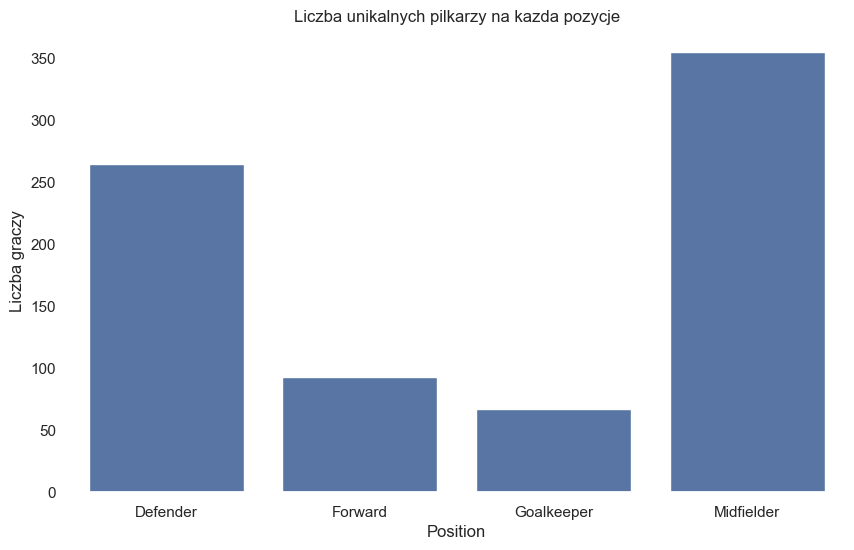

In [56]:
plt.figure(figsize=(10,6))
sns.barplot(data.groupby("position_id")["web_name_id"].nunique())
plt.title("Liczba unikalnych pilkarzy na kazda pozycje")
plt.xlabel("Position")
plt.ylabel("Liczba graczy")

In [57]:
[c for c in data.columns if "points" in c]

['event_points', 'total_points']

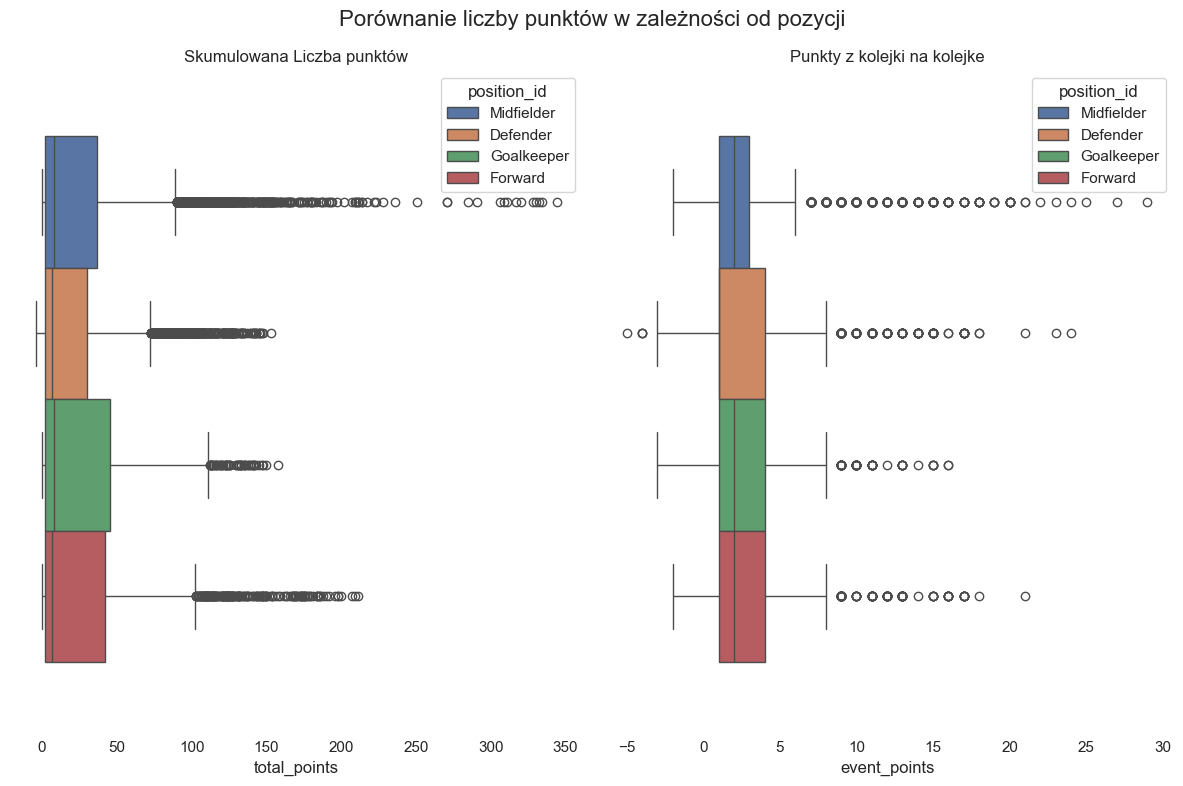

In [58]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

sns.boxplot(data=data, x="total_points", hue="position_id", ax=ax[0])
sns.boxplot(data=data, x="event_points", hue="position_id", ax=ax[1])

ax[0].set_title("Skumulowana Liczba punktów")
ax[1].set_title("Punkty z kolejki na kolejke")
fig.suptitle("Porównanie liczby punktów w zależności od pozycji", fontsize=16)

plt.tight_layout()


Text(0.5, 1.0, 'Rozkład Event Points')

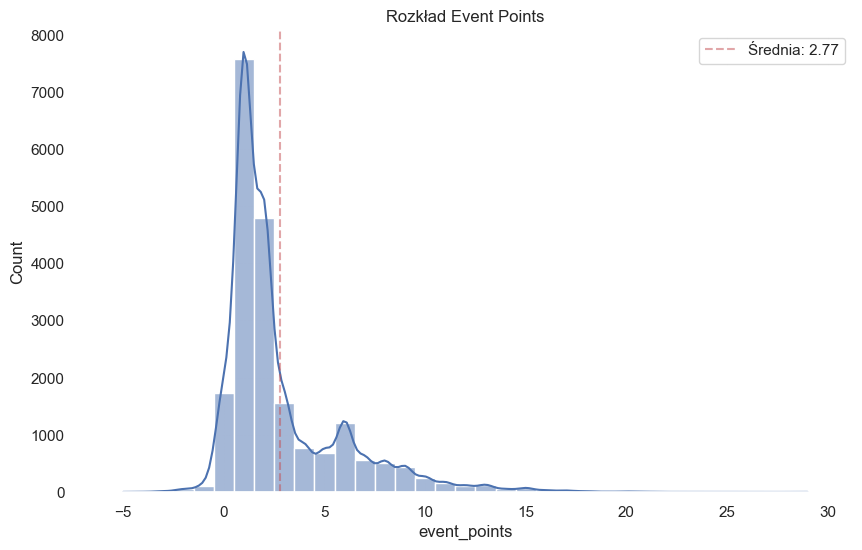

In [59]:
plt.figure(figsize=(10,6))

ax = sns.histplot(data.event_points,
             kde=True,
             discrete=True,
             bins=30)
ax.axvline(data.event_points.mean(), linestyle="--", color="r", alpha=0.5, label=f"Średnia: {data.event_points.mean():.2f}")
plt.legend(loc="upper right")
plt.title("Rozkład Event Points")

<Axes: >

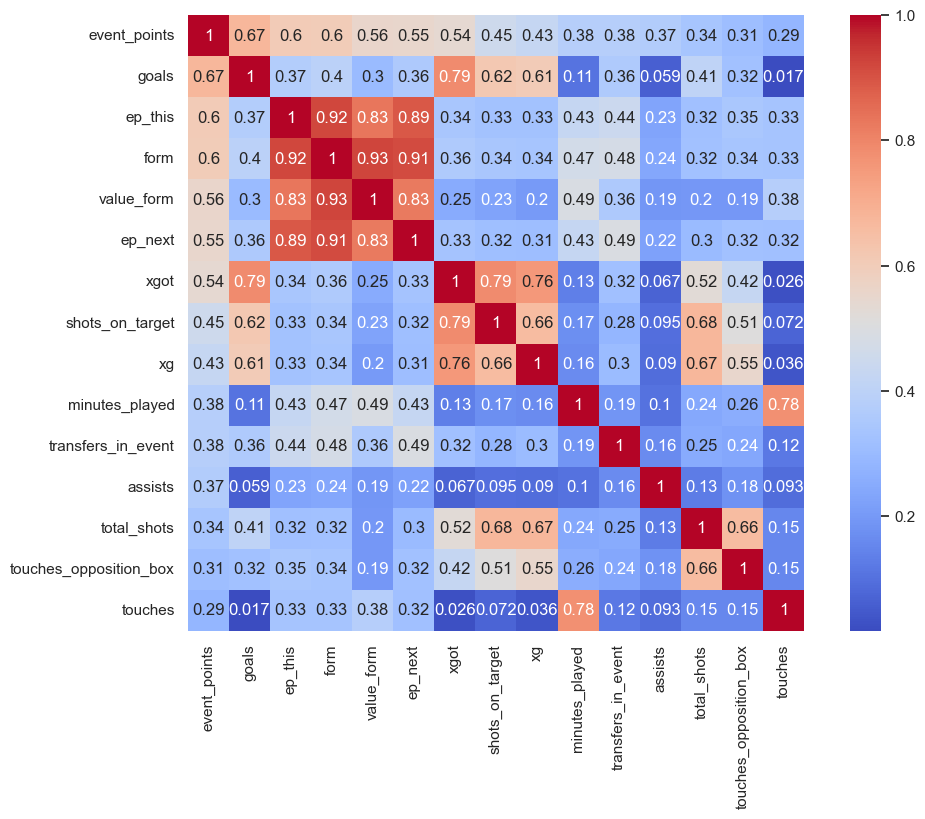

In [60]:
corr = data.select_dtypes(exclude=["object", "string"]).corr().apply(np.abs)
cols = corr["event_points"].sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(corr.loc[cols, cols], annot=True, cmap="coolwarm", square=True)

In [61]:
best_players_plots(df=data,
                   num_players=10,
                   season=2526)

KeyError: 'web_name'

In [62]:
data["value_ratio"] = (data.event_points / data.now_cost).fillna(0)


In [63]:
data[["web_name_id", "value_ratio", "position_id", "gw_id", "season_id"]].sort_values(by="value_ratio", ascending=False).head()

,web_name_id,value_ratio,position_id,gw_id,season_id
18854,Van de Ven,4.893617,Defender,9,2526
7153,Barnes,4.576271,Midfielder,32,2425
20384,Schade,4.509804,Midfielder,13,2425
13508,Lewis-Potter,4.375,Defender,17,2526
15402,J.Timber,4.363636,Defender,2,2526


In [64]:
x_cols = [c for c in data.columns if "expected" in c]

In [65]:
x_cols

['expected_goals_conceded',
 'expected_goals',
 'expected_assists',
 'expected_goal_involvements',
 'expected_goal_involvements_per_90',
 'expected_goals_conceded_per_90']

In [66]:
data.columns.to_list()[:10]

['web_name_id',
 'first_name_id',
 'second_name_id',
 'status_id',
 'team_name_id',
 'position_id',
 'season_id',
 'player_code_id',
 'team_code_id',
 'gw_id']

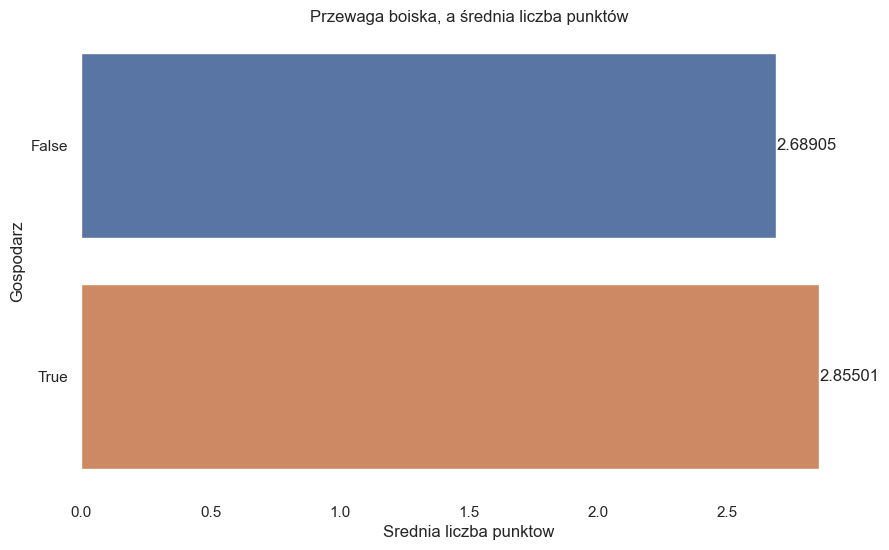

In [67]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=data,
    y="was_home",
    x="event_points",
    hue="was_home",
    estimator="mean",
    legend=False,
    errorbar=None,
    orient="h")

plt.xlabel("Srednia liczba punktow")
plt.ylabel("Gospodarz")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Przewaga boiska, a średnia liczba punktów");

In [68]:
teams_avenue_form = data.groupby(["season_id", "team_name_id", "was_home"])["event_points"].mean().reset_index()
teams_avenue_form = teams_avenue_form.pivot(index=["season_id", "team_name_id"], columns="was_home", values="event_points")

# Zmień na 1 i 0 jeśli Twoje was_home to zera i jedynki
teams_avenue_form["home_advantage"] = teams_avenue_form[True] - teams_avenue_form[False]

# Zostawiamy nazwy drużyn i sezonu, zamieniając je z powrotem na zwykłe kolumny!
teams_avenue_form.reset_index(inplace=True)

teams_avenue_form.sort_values(by="home_advantage", ascending=False, inplace=True)
teams_avenue_form.columns.name = None

In [69]:
teams_avenue_form.head()

,season_id,team_name_id,False,True,home_advantage
37,2526,Sunderland,2.369099,3.374408,1.005309
33,2526,Man Utd,2.665272,3.45045,0.785178
1,2425,Aston Villa,2.576052,3.314879,0.738827
14,2425,Newcastle,2.800687,3.462069,0.661382
30,2526,Leeds,2.3,2.902041,0.602041


In [70]:
teams_avenue_form.tail()

,season_id,team_name_id,False,True,home_advantage
38,2526,West Ham,2.617284,2.331776,-0.285508
12,2425,Man City,3.426966,3.138298,-0.288668
28,2526,Everton,3.204651,2.91453,-0.290121
18,2425,West Ham,2.541935,2.205298,-0.336637
36,2526,Spurs,3.12381,2.340517,-0.783292


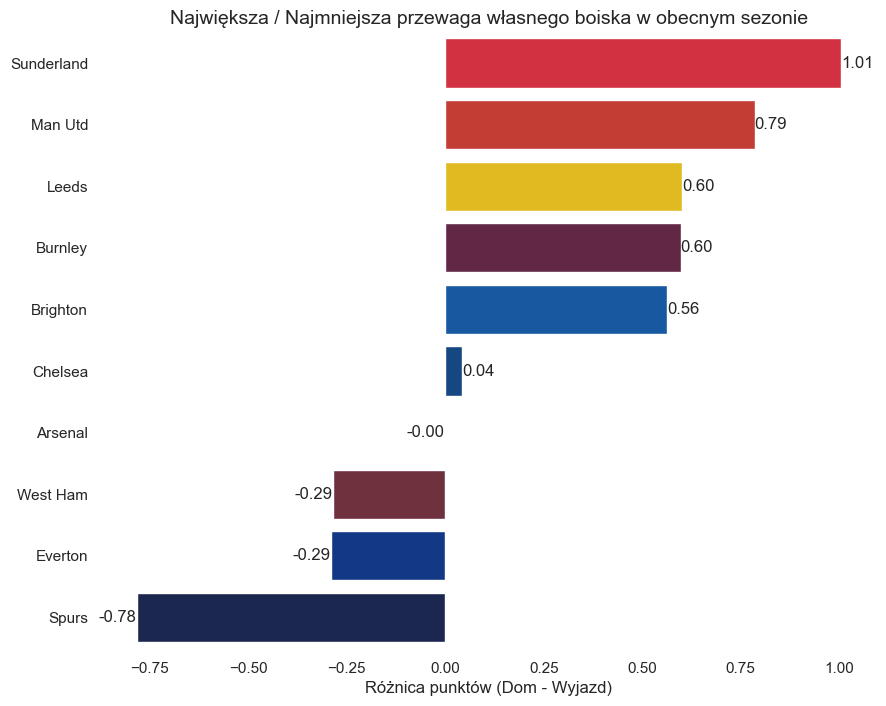

In [71]:
plt.figure(figsize=(10, 8))
ax =sns.barplot(data=pd.concat([teams_avenue_form[teams_avenue_form.season_id==2526].head(), teams_avenue_form[teams_avenue_form.season_id==2526].tail()], axis=0),
            x="home_advantage",
            hue="team_name_id",
            y="team_name_id",
            palette=colors_config.team_colors,
            errorbar=None)
plt.title("Największa / Najmniejsza przewaga własnego boiska w obecnym sezonie", fontsize=14)
plt.xlabel("Różnica punktów (Dom - Wyjazd)")
plt.ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")


In [72]:
team_names = [t for t in data[data.season_id==2526].team_name_id.unique()]
team_names

['Brighton',
 'Everton',
 'Newcastle',
 'Burnley',
 'Bournemouth',
 'Brentford',
 'Crystal Palace',
 'Leeds',
 "Nott'm Forest",
 'Man Utd',
 'Aston Villa',
 'Sunderland',
 'West Ham',
 'Fulham',
 'Wolves',
 'Man City',
 'Liverpool',
 'Chelsea',
 'Arsenal',
 'Spurs']

In [73]:
data[data.season_id==2526].gw_id.unique()

<IntegerArray>
[ 1,  3,  4,  5,  7,  8,  9, 16, 17, 19, 20, 21, 23, 24, 26, 27, 28, 29,  2,
  6, 10, 11, 12, 13, 14, 15, 18, 22, 25]
Length: 29, dtype: Int64

In [74]:
[c for c in data.columns if "sele" in c]

['selected_rank', 'selected_by_percent']

In [75]:
data.position_id.unique()

<ArrowStringArray>
['Midfielder', 'Defender', 'Goalkeeper', 'Forward']
Length: 4, dtype: string

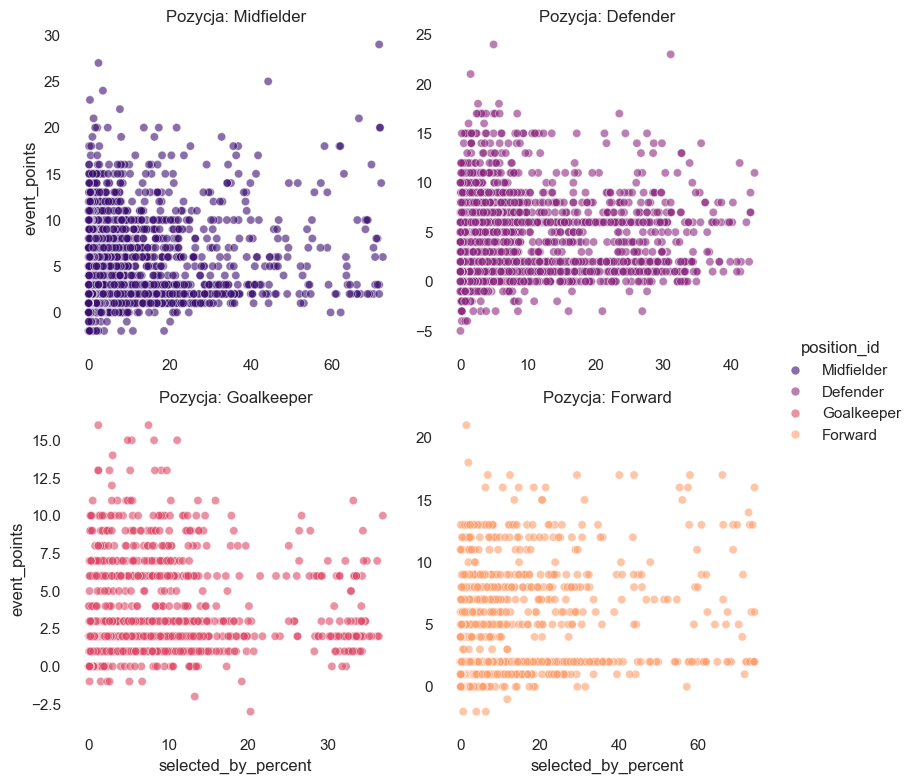

In [76]:
g = sns.relplot(
    data=data,
    x="selected_by_percent",
    y="event_points",
    col="position_id",
    hue="position_id",
    col_wrap=2,
    palette="magma",
    kind="scatter",
    alpha=0.6,
    height=4,
    facet_kws={'sharex': False, 'sharey': False}

)

g.set_titles("Pozycja: {col_name}")

plt.show()

In [78]:
data.to_parquet(config.TIDY_DATA_PATH)